In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
import os
import pathlib
import tensorflow as tf

# The Google Cloud Storage URL for the flowers dataset
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"

# Download and extract the archive
data_dir = tf.keras.utils.get_file('flower_photos.tgz', origin=dataset_url, extract=True)

# Define the path to the extracted image folders
data_dir = pathlib.Path(data_dir).with_suffix('') 

print(f"Flower photos are located in: {data_dir}")

228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Flower photos are located in: /root/.keras/datasets/flower_photos_extracted


In [3]:
!wget -q https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz
!tar -xzf flower_photos.tgz -C /kaggle/working/

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import os

In [5]:
# Simple hyperparameter setup
EPOCHS = 10
BATCH_SIZE = 16
LEARNING_RATE = 0.001
INPUT_SIZE = 128

In [6]:
# Set device to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [7]:
# Standard AlexNet ImageNet transforms
transform = transforms.Compose([
    transforms.Resize((INPUT_SIZE, INPUT_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [8]:
# Load the full extracted dataset
data_dir = "/kaggle/working/flower_photos"
full_dataset = datasets.ImageFolder(root=data_dir, transform=transform)

In [9]:
# Split 80% for training, 20% for validation
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

In [10]:
# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

In [11]:
print(f"Training images: {len(train_dataset)} | Validation images: {len(val_dataset)}")

Training images: 2936 | Validation images: 734


In [12]:
# Load Pretrained AlexNet
alexnet = models.alexnet(weights=models.AlexNet_Weights.IMAGENET1K_V1)

Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 219MB/s] 


In [13]:
# Freeze early layers so we don't destroy pretrained features
for param in alexnet.parameters():
    param.requires_grad = False

In [14]:
# Replace the final classifier layer (4096 input features -> 5 flower classes)
alexnet.classifier[6] = nn.Linear(4096, 5)

In [15]:
# Move the model to the GPU
alexnet = alexnet.to(device)

In [16]:
# Define Loss and Optimizer (Only optimize the new, unfrozen layer!)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(alexnet.classifier[6].parameters(), lr=LEARNING_RATE)

In [17]:
def train_model(model, criterion, optimizer, train_loader, val_loader, epochs=10):
    # Dictionary to store metrics
    history = {'train_loss': [], 'train_acc': [], 'val_acc': []}
    
    for epoch in range(epochs):
        model.train()
        train_correct = 0
        train_total = 0
        running_loss = 0.0

        print(f"\nEpoch {epoch + 1}/{epochs}")
        print("-" * 30)

        for i, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            batch_correct = (preds == labels).sum().item()
            train_correct += batch_correct
            train_total += labels.size(0)

            # Print every 20 batches
            if (i + 1) % 20 == 0:
                batch_acc = batch_correct / labels.size(0)
                print(f"[Batch {i+1}/{len(train_loader)}] Loss: {loss.item():.4f}, Batch Acc: {batch_acc:.4f}")

        train_acc = train_correct / train_total
        print(f"Epoch {epoch+1} Summary - Loss: {running_loss:.4f}, Train Accuracy: {train_acc:.4f}")

        # Validation Loop
        model.eval()
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, preds = torch.max(outputs, 1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_acc = val_correct / val_total
        print(f"Validation Accuracy: {val_acc:.4f}")
        
        # Save metrics for this epoch
        history['train_loss'].append(running_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        
    return history

In [18]:
# Execute the training and save the results
history = train_model(alexnet, criterion, optimizer, train_loader, val_loader, epochs=EPOCHS)


Epoch 1/10
------------------------------
[Batch 20/184] Loss: 0.8777, Batch Acc: 0.6875
[Batch 40/184] Loss: 0.8678, Batch Acc: 0.8125
[Batch 60/184] Loss: 0.4832, Batch Acc: 0.6875
[Batch 80/184] Loss: 0.5499, Batch Acc: 0.7500
[Batch 100/184] Loss: 0.5038, Batch Acc: 0.8125
[Batch 120/184] Loss: 0.4342, Batch Acc: 0.8750
[Batch 140/184] Loss: 0.4199, Batch Acc: 0.8750
[Batch 160/184] Loss: 0.8581, Batch Acc: 0.7500
[Batch 180/184] Loss: 1.2977, Batch Acc: 0.8125
Epoch 1 Summary - Loss: 136.9169, Train Accuracy: 0.7667
Validation Accuracy: 0.8120

Epoch 2/10
------------------------------
[Batch 20/184] Loss: 0.2528, Batch Acc: 0.9375
[Batch 40/184] Loss: 0.7090, Batch Acc: 0.8750
[Batch 60/184] Loss: 0.7958, Batch Acc: 0.7500
[Batch 80/184] Loss: 0.5600, Batch Acc: 0.8125
[Batch 100/184] Loss: 0.1386, Batch Acc: 0.9375
[Batch 120/184] Loss: 0.7440, Batch Acc: 0.7500
[Batch 140/184] Loss: 1.2277, Batch Acc: 0.6250
[Batch 160/184] Loss: 0.0242, Batch Acc: 1.0000
[Batch 180/184] Loss:

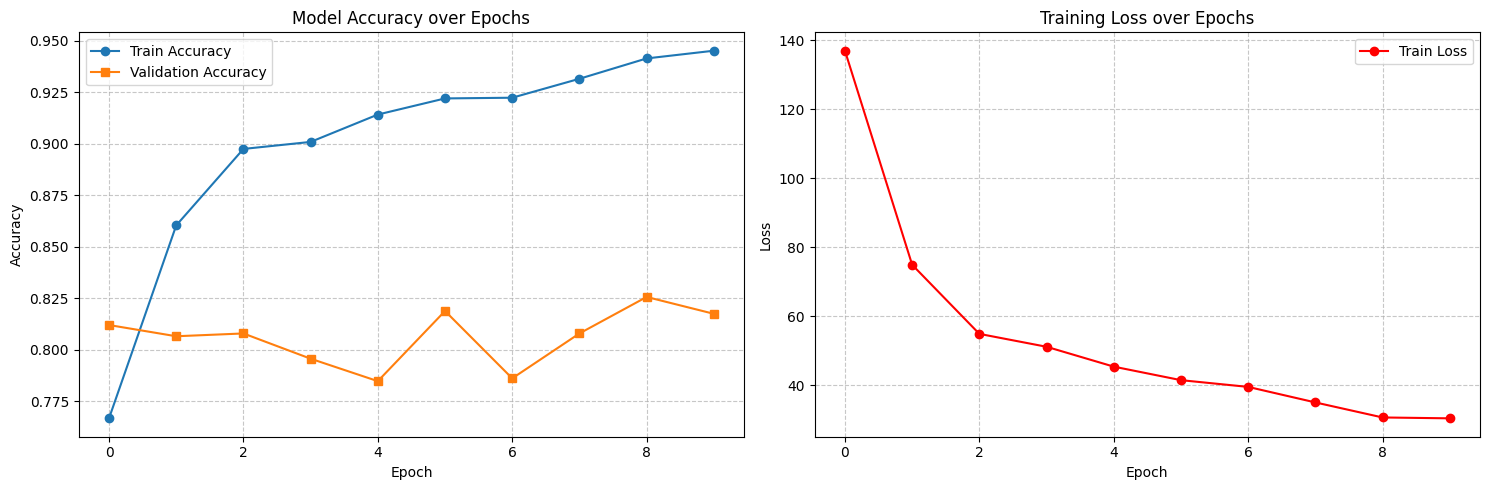

In [19]:
import matplotlib.pyplot as plt

# Set up a figure with two subplots (1 row, 2 columns)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot Accuracy
ax1.plot(history['train_acc'], label='Train Accuracy', marker='o')
ax1.plot(history['val_acc'], label='Validation Accuracy', marker='s')
ax1.set_title('Model Accuracy over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

# Plot Loss
ax2.plot(history['train_loss'], label='Train Loss', color='red', marker='o')
ax2.set_title('Training Loss over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [20]:
# Save the trained weights to the working directory
torch.save(alexnet.state_dict(), '/kaggle/working/alexnet_flower_model.pth')
print("Model weights saved successfully!")

Model weights saved successfully!


In [21]:
import random

# Get the list of class names from the dataset
class_names = full_dataset.classes

In [22]:
# Set model to evaluation mode
alexnet.eval()

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

In [23]:
# Pick a random image from the validation set
random_idx = random.randint(0, len(val_dataset) - 1)
image_tensor, actual_label_idx = val_dataset[random_idx]

In [24]:
# Add a batch dimension (C, H, W) -> (1, C, H, W) and move to GPU
image_batch = image_tensor.unsqueeze(0).to(device)

In [25]:
# Make the prediction
with torch.no_grad():
    output = alexnet(image_batch)
    _, predicted_idx = torch.max(output, 1)

In [26]:
# Extract the class names
actual_flower = class_names[actual_label_idx]
predicted_flower = class_names[predicted_idx.item()]

In [27]:
# Plot the result
# Un-normalize the image for displaying
image_display = image_tensor.permute(1, 2, 0).numpy()
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]
image_display = std * image_display + mean
image_display = image_display.clip(0, 1)

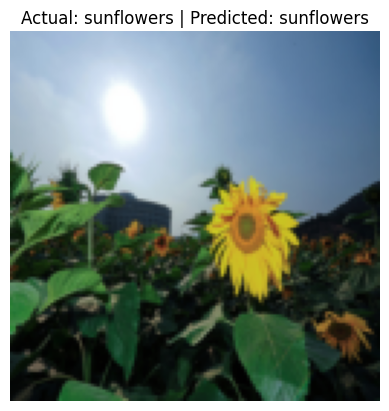

In [28]:
plt.imshow(image_display)
plt.title(f"Actual: {actual_flower} | Predicted: {predicted_flower}")
plt.axis('off')
plt.show()